**Meta Learner V1 preparing data and preprocessing and trianing**

#1:Load Base GPT2 model

In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

print("GPT-2 base model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 base model and tokenizer loaded successfully.


**Loading  Dataset**
* tinystores dataset is used

In [2]:
from datasets import load_dataset

print("Loading TinyStories subset...")

# Load only 5% of train + 5% of validation
dataset = load_dataset(
    "roneneldan/TinyStories",
    split={
        "train": "train[:5%]",
        "validation": "validation[:5%]"
    }
)

print("TinyStories subset loaded successfully!")
print(dataset)

Loading TinyStories subset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

TinyStories subset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 105986
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1100
    })
})


**Tokanizing dataset**

In [4]:
import os

In [5]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512)

print("Tokenizing dataset...")
tokenized_dataset = dataset.map(tokenize_function, batched=True, num_proc=os.cpu_count(), remove_columns=["text"])
print("Dataset tokenization complete!")
print(tokenized_dataset)

Tokenizing dataset...


Map (num_proc=2):   0%|          | 0/105986 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1100 [00:00<?, ? examples/s]

Dataset tokenization complete!
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 105986
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 1100
    })
})


In [6]:
import torch
import math
import json
import os
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import DataCollatorForLanguageModeling

# ======================================================
# FIX GPT-2 PADDING (CRITICAL)
# ======================================================

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# ======================================================
# SIMPLE META LOGGER (COLAB SAFE)
# ======================================================

class SimpleMetaLogger:
    def __init__(self, file_path="meta_logs.jsonl"):
        self.file_path = file_path
        self.prev_loss = None
        self.f = open(self.file_path, "w")

    def log(self, data_dict):
        self.f.write(json.dumps(data_dict) + "\n")
        self.f.flush()

    def close(self):
        self.f.close()


# ======================================================
# HELPER FUNCTIONS
# ======================================================

def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return math.sqrt(total)


def global_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.detach().norm(2).item() ** 2
    return math.sqrt(total)


def layer_grad_stats(model):
    norms = []
    for p in model.parameters():
        if p.grad is not None:
            norms.append(p.grad.detach().norm(2).item())
    if len(norms) == 0:
        return 0.0, 0.0
    return float(np.mean(norms)), float(np.std(norms))


def attention_entropy(attentions):
    if attentions is None:
        return 0.0, 0.0

    entropies = []

    for attn in attentions:
        if attn is None:
            continue

        # attn shape: (B, heads, seq, seq)
        probs = torch.clamp(attn.detach(), min=1e-9)
        entropy = -(probs * torch.log(probs)).sum(dim=-1)
        entropies.append(entropy.mean().item())

    if len(entropies) == 0:
        return 0.0, 0.0

    return float(np.mean(entropies)), float(np.std(entropies))


# ======================================================
# TRAINING SETUP
# ======================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.train()

optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
scaler = torch.amp.GradScaler("cuda")

batch_size = 4
gradient_accumulation_steps = 8
max_steps = 10000  # adjust if needed

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator
)

logger = SimpleMetaLogger("meta_logs.jsonl")

optimizer.zero_grad()
step = 0

progress_bar = tqdm(train_dataloader)

# ======================================================
# TRAINING LOOP
# ======================================================

for batch in progress_bar:

    if step >= max_steps:
        break

    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"],
            output_attentions=True
        )

        loss = outputs.loss / gradient_accumulation_steps

    scaler.scale(loss).backward()

    if (step + 1) % gradient_accumulation_steps == 0:

        raw_loss = loss.item() * gradient_accumulation_steps

        # ===== Collect Metrics BEFORE optimizer step =====
        grad_norm = global_grad_norm(model)
        weight_norm = global_weight_norm(model)
        lr = optimizer.param_groups[0]["lr"]
        update_ratio = (lr * grad_norm) / (weight_norm + 1e-9)

        layer_mean, layer_std = layer_grad_stats(model)
        attn_mean, attn_std = attention_entropy(outputs.attentions)

        delta_loss = 0.0
        if logger.prev_loss is not None:
            delta_loss = raw_loss - logger.prev_loss
        logger.prev_loss = raw_loss

        fp16_overflow = scaler.get_scale() < 1

        logger.log({
            "loss": raw_loss,
            "delta_loss": delta_loss,
            "lr": lr,
            "grad_norm": grad_norm,
            "update_ratio": update_ratio,
            "layer_grad_mean": layer_mean,
            "layer_grad_std": layer_std,
            "attn_entropy_mean": attn_mean,
            "attn_entropy_std": attn_std,
            "expert_load_entropy": 0.0,
            "activation_sparsity": 0.0,
            "fp16_overflow": int(fp16_overflow)
        })

        # ===== Optimizer Step =====
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        progress_bar.set_description(f"Loss: {raw_loss:.4f}")

    step += 1

logger.close()

print("Training complete. Logs saved to meta_logs.jsonl")

  0%|          | 7/26497 [00:02<1:32:32,  4.77it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
Loss: 1.0856:  38%|███▊      | 10000/26497 [24:20<40:09,  6.85it/s]

Training complete. Logs saved to meta_logs.jsonl


In [7]:
from datasets import load_dataset

print("Loading TinyStories subset...")

# Load only 5% of train + 5% of validation
dataset = load_dataset(
    "roneneldan/TinyStories",
    split={
        "train": "train[:5%]",
        "validation": "validation[:5%]"
    }
)

print("TinyStories subset loaded successfully!")
print(dataset)

Loading TinyStories subset...
TinyStories subset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 105986
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1100
    })
})


In [8]:
import pandas as pd
import numpy as np

df = pd.read_json("meta_logs.jsonl", lines=True)

print("Raw rows:", len(df))
df.head()

Raw rows: 1250


,loss,delta_loss,lr,grad_norm,update_ratio,layer_grad_mean,layer_grad_std,attn_entropy_mean,attn_entropy_std,expert_load_entropy,activation_sparsity,fp16_overflow
0,3.686828,0.000000,0.00003,inf,inf,inf,NaN,0,0,0,0,0
1,4.539477,0.852649,0.00003,inf,inf,inf,NaN,0,0,0,0,0
2,4.305472,-0.234004,0.00003,inf,inf,inf,NaN,0,0,0,0,0
3,4.445694,0.140222,0.00003,inf,inf,inf,NaN,0,0,0,0,0
4,3.634201,-0.811493,0.00003,2.701561e+05,0.005383,7420.986771,20930.032084,0,0,0,0,0


In [9]:
# Replace inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN
df.dropna(inplace=True)

print("Clean rows:", len(df))

Clean rows: 1246


In [10]:
df["target"] = df["delta_loss"].shift(-1)
df.dropna(inplace=True)

print("Final rows:", len(df))

Final rows: 1245


In [11]:
feature_columns = [
    "loss",
    "delta_loss",
    "lr",
    "grad_norm",
    "update_ratio",
    "layer_grad_mean",
    "layer_grad_std",
    "attn_entropy_mean",
    "attn_entropy_std",
    "fp16_overflow"
]

X = df[feature_columns]
y = df["target"]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature shape:", X_scaled.shape)

Feature shape: (1245, 10)


In [13]:
df_final = pd.DataFrame(X_scaled, columns=feature_columns)
df_final["target"] = y.values

df_final.to_csv("meta_dataset_clean.csv", index=False)

print("Saved meta_dataset_clean.csv")

Saved meta_dataset_clean.csv


**both files are available**

#meta_logs.jsonl

#meta_dataset_clean.csv

We now move to the most important part:

**🚀 MetaLearner v1 — Training the Model**

Goal:

* Learn mapping

*𝑆
𝑡
→
Δ
𝑙
𝑜
𝑠
𝑠
𝑡
+
1
S
t
	​

→Δloss
t+1
	​


* Then later convert that into LR controller.

**step 7:
Train MetaLearner v1 (Proper Version**



*   Load your cleaned dataset
*   Split train/validation
*   Train MLP
*   Track MSE
*   Save model


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Load dataset
df = pd.read_csv("meta_dataset_clean.csv")

print("Dataset shape:", df.shape)

X = df.drop(columns=["target"]).values
y = df["target"].values

Dataset shape: (1245, 11)


In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [22]:
class MetaLearner(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MetaLearner(input_dim=X.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 100

In [26]:
for epoch in range(epochs):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.6f} | "
          f"Val Loss: {val_loss/len(val_loader):.6f}")

Epoch 1/100 | Train Loss: 0.150493 | Val Loss: 0.122074
Epoch 2/100 | Train Loss: 0.105235 | Val Loss: 0.096423
Epoch 3/100 | Train Loss: 0.094690 | Val Loss: 0.087224
Epoch 4/100 | Train Loss: 0.089828 | Val Loss: 0.085012
Epoch 5/100 | Train Loss: 0.086707 | Val Loss: 0.083817
Epoch 6/100 | Train Loss: 0.086670 | Val Loss: 0.084369
Epoch 7/100 | Train Loss: 0.084781 | Val Loss: 0.083293
Epoch 8/100 | Train Loss: 0.085674 | Val Loss: 0.084451
Epoch 9/100 | Train Loss: 0.086728 | Val Loss: 0.083415
Epoch 10/100 | Train Loss: 0.084629 | Val Loss: 0.084744
Epoch 11/100 | Train Loss: 0.085146 | Val Loss: 0.082924
Epoch 12/100 | Train Loss: 0.083624 | Val Loss: 0.083117
Epoch 13/100 | Train Loss: 0.081941 | Val Loss: 0.083190
Epoch 14/100 | Train Loss: 0.082522 | Val Loss: 0.083417
Epoch 15/100 | Train Loss: 0.082564 | Val Loss: 0.082878
Epoch 16/100 | Train Loss: 0.083270 | Val Loss: 0.084021
Epoch 17/100 | Train Loss: 0.082307 | Val Loss: 0.082719
Epoch 18/100 | Train Loss: 0.081851 | Va

In [27]:
torch.save(model.state_dict(), "meta_learner_v1.pt")
print("MetaLearner v1 saved.")

MetaLearner v1 saved.


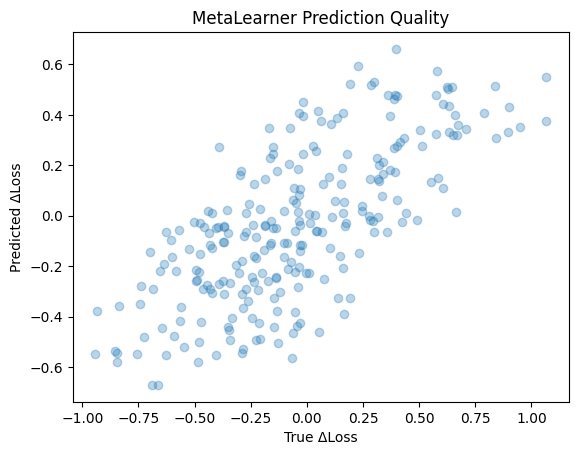

In [28]:
model.eval()
with torch.no_grad():
    preds = model(X_val.to(device)).cpu().numpy()

import matplotlib.pyplot as plt

plt.scatter(y_val.numpy(), preds, alpha=0.3)
plt.xlabel("True ΔLoss")
plt.ylabel("Predicted ΔLoss")
plt.title("MetaLearner Prediction Quality")
plt.show()

**Re-run GPT-2 on TinyStories**

* Inject MetaLearner as LR controller

* Compare convergence curve vs baseline

In [36]:
# ======================================================
# IMPORTS
# ======================================================

import torch
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    DataCollatorForLanguageModeling
)
from sklearn.preprocessing import StandardScaler

device = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================
# LOAD GPT-2
# ======================================================

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(model_name)

tokenizer.pad_token = tokenizer.eos_token
gpt_model.config.pad_token_id = tokenizer.eos_token_id

gpt_model.to(device)
gpt_model.train()

print("GPT-2 loaded.")

# ======================================================
# LOAD METALEARNER
# ======================================================

class MetaLearner(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

meta_df = pd.read_csv("meta_dataset_clean.csv")
feature_columns = meta_df.columns[:-1]

scaler_meta = StandardScaler()
scaler_meta.fit(meta_df[feature_columns].values)

meta_model = MetaLearner(input_dim=len(feature_columns))
meta_model.load_state_dict(torch.load("meta_learner_v1.pt", map_location=device))
meta_model.to(device)
meta_model.eval()

print("MetaLearner loaded.")

# ======================================================
# HELPER FUNCTIONS (SAFE)
# ======================================================

def safe_value(x):
    if np.isnan(x) or np.isinf(x):
        return 0.0
    return float(np.clip(x, -1e6, 1e6))

def global_grad_norm(model):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().norm(2).item() ** 2
    return safe_value(math.sqrt(total))

def global_weight_norm(model):
    total = 0.0
    for p in model.parameters():
        total += p.detach().norm(2).item() ** 2
    return safe_value(math.sqrt(total))

def layer_grad_stats(model):
    norms = []
    for p in model.parameters():
        if p.grad is not None:
            norms.append(p.grad.detach().norm(2).item())
    if len(norms) == 0:
        return 0.0, 0.0
    return safe_value(np.mean(norms)), safe_value(np.std(norms))

def attention_entropy(attentions):
    if attentions is None:
        return 0.0, 0.0
    entropies = []
    for attn in attentions:
        if attn is None:
            continue
        probs = torch.clamp(attn.detach(), min=1e-9)
        entropy = -(probs * torch.log(probs)).sum(dim=-1)
        entropies.append(entropy.mean().item())
    if len(entropies) == 0:
        return 0.0, 0.0
    return safe_value(np.mean(entropies)), safe_value(np.std(entropies))

# ======================================================
# TRAINING SETUP
# ======================================================

base_lr = 3e-5
optimizer = AdamW(gpt_model.parameters(), lr=base_lr, weight_decay=0.01)
scaler = torch.amp.GradScaler("cuda")

batch_size = 4
gradient_accumulation_steps = 8
max_steps = 6000

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=batch_size,
    collate_fn=data_collator
)

print("Training setup ready.")

# ======================================================
# TRAINING LOOP (SAFE CONTROLLER)
# ======================================================

optimizer.zero_grad()
step = 0
prev_loss = None

loss_history = []
lr_history = []

progress_bar = tqdm(train_dataloader)

for batch in progress_bar:

    if step >= max_steps:
        break

    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        outputs = gpt_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["input_ids"],
            output_attentions=True
        )
        loss = outputs.loss / gradient_accumulation_steps

    scaler.scale(loss).backward()

    if (step + 1) % gradient_accumulation_steps == 0:

        raw_loss = safe_value(loss.item() * gradient_accumulation_steps)

        grad_norm = global_grad_norm(gpt_model)
        weight_norm = global_weight_norm(gpt_model)
        lr_current = optimizer.param_groups[0]["lr"]

        update_ratio = safe_value(
            (lr_current * grad_norm) / (weight_norm + 1e-9)
        )

        layer_mean, layer_std = layer_grad_stats(gpt_model)
        attn_mean, attn_std = attention_entropy(outputs.attentions)

        delta_loss = 0.0 if prev_loss is None else safe_value(raw_loss - prev_loss)
        prev_loss = raw_loss

        fp16_overflow = scaler.get_scale() < 1

        state_np = np.array([[
            raw_loss,
            delta_loss,
            lr_current,
            grad_norm,
            update_ratio,
            layer_mean,
            layer_std,
            attn_mean,
            attn_std,
            float(fp16_overflow)
        ]], dtype=np.float32)

        # Final safety check
        if np.any(np.isnan(state_np)) or np.any(np.isinf(state_np)):
            new_lr = base_lr
        else:
            state_scaled = scaler_meta.transform(state_np)
            state_tensor = torch.tensor(state_scaled, dtype=torch.float32).to(device)

            with torch.no_grad():
                pred_delta = meta_model(state_tensor)

            alpha = 0.25
            lr_multiplier = 1 - alpha * torch.tanh(pred_delta)
            lr_multiplier = torch.clamp(lr_multiplier, 0.8, 1.2)

            if step < 500:
                lr_multiplier = torch.tensor([[1.0]], device=device)

            new_lr = base_lr * lr_multiplier.item()

        optimizer.param_groups[0]["lr"] = new_lr

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        loss_history.append(raw_loss)
        lr_history.append(new_lr)

        progress_bar.set_description(
            f"Loss: {raw_loss:.4f} | LR: {new_lr:.2e}"
        )

    step += 1

print("Controlled training complete.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 loaded.
MetaLearner loaded.
Training setup ready.


  0%|          | 7/26497 [00:01<1:03:35,  6.94it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
Loss: 3.5237 | LR: 3.00e-05:   0%|          | 15/26497 [00:02<1:02:28,  7.06it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
Loss: 5.8876 | LR: 3.00e-05:   0%|          | 23/26497 [00:03<1:17:15,  5.71it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
Loss: 3.9096 | LR: 3.00e-05:   0%|          | 31/26497 [00:04<1:01:57,  7.12it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
Loss: 1.4958 | LR: 2.40e-05:  23%|██▎       | 6000/26497 [14:42<50:15,  6.80it/s]

Controlled training complete.


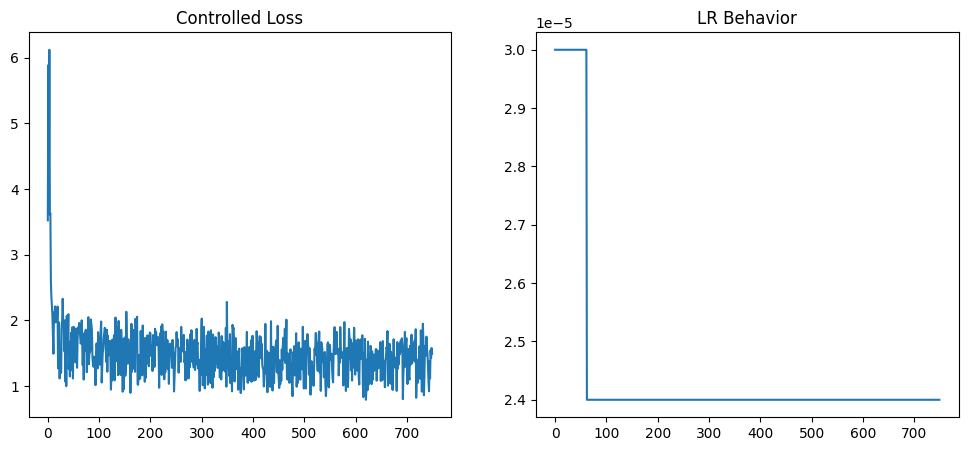

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Controlled Loss")

plt.subplot(1,2,2)
plt.plot(lr_history)
plt.title("LR Behavior")
plt.show()